<a href="https://colab.research.google.com/github/UbaidMalik365/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/UbaidMalik365/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

### Research Question

Which web pages should be prioritized for content refresh based on observable search-performance signals?

The goal is to rank pages that are more likely to be declining so that a human content team can review the highest-priority pages first.

### Decision Supported

The output is intended as decision-support for prioritizing content refresh work. It does not automatically decide which pages should be changed.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

In [9]:
import os
import pandas as pd

os.chdir("/content/flyrank-ml-internship-starter")

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")

print("Dataset shape:", df.shape)
print("Columns:", len(df.columns))

df.head()

Dataset shape: (30000, 44)
Columns: 44


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


### Data

This analysis uses the FlyRank internship warehouse dataset and focuses on page-level search and content-performance information.

The working dataset contains 30,000 rows and 44 columns. Each row represents one content page with observable fields such as search volume, impressions, clicks, sessions, content age, days since last update, CTR, average position, and trend direction.

The target label `is_declining_label` is derived from `trend_direction`: pages with a `down` trend are labeled as declining.

The analysis uses historical observable features and excludes future-window information and label-derived features from the model inputs to reduce leakage risk.

The final evaluation also uses a grouped-by-client validation design so that clients in the training and testing sets do not overlap.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

### Methodology

The task is treated as a classification and ranking problem.

The target is `is_declining_label`, where a page is labeled declining when its `trend_direction` is `down`.

The Decision Tree model uses observable page-level features including content age, days since last update, impressions, average position, CTR, and word count.

The Week-4 baseline provides a simple rule-based comparison. The Week-5 model is evaluated using Precision@50 because the practical goal is to place useful declining pages near the top of a review queue.

The initial Week-5 evaluation used a random split. Week-6 then tested a stricter grouped-by-client split, with 25 clients in training and 7 clients in testing and no clients shared between the two sets.

A leakage audit was performed to avoid using label-derived or future-window information as model features.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [10]:
comparison = pd.DataFrame({
    "Validation design": [
        "Week-4 baseline",
        "Week-5 Decision Tree",
        "Week-6 Decision Tree - grouped by client"
    ],
    "Precision@50": [
        0.46,
        0.70,
        0.58
    ]
})

comparison

,Validation design,Precision@50
0,Week-4 baseline,0.46
1,Week-5 Decision Tree,0.70
2,Week-6 Decision Tree - grouped by client,0.58


### Results

The Week-5 Decision Tree improved on the Week-4 baseline under the original evaluation setup.

The baseline achieved Precision@50 of 0.46, while the Decision Tree achieved 0.70 under the Week-5 random split.

However, the stricter grouped-by-client validation produced Precision@50 of 0.58. This is lower than the random-split result and provides a more conservative estimate because the model was tested on clients that were not present in training.

The results therefore suggest that the model can rank declining pages better than the simple baseline, but performance is sensitive to validation design.

## 5. Limitations

*What this work cannot claim.*

### Limitations

This analysis has several limitations.

First, the dataset contains observable search and content-performance signals but cannot explain every reason a page's performance changes.

Second, the model predicts or ranks pages associated with a declining trend; it does not prove that refreshing a page will improve its future performance.

Third, the random-split result is more optimistic than the grouped-by-client result. The grouped result is therefore treated as the more conservative validation evidence.

Fourth, some declining pages will not appear in the top-ranked results, while some highly ranked pages will not actually be declining.

Finally, this work is decision-support rather than an automated production decision system. Human review is required before taking content action.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

### Ranked Recommendations

The model output should be used as a prioritized review queue.

Pages near the top of the ranking should be reviewed first because they have stronger combinations of observable signals associated with declining performance.

Recommended workflow:

1. Review the highest-ranked pages first.
2. Check whether the page has meaningful search visibility.
3. Check content age and time since the last update.
4. Review impressions, CTR, and average position together rather than relying on one signal.
5. Confirm that the page is actually suitable for a content refresh.
6. A human reviewer makes the final decision.

The ranking should not automatically publish, delete, rewrite, or redirect content.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

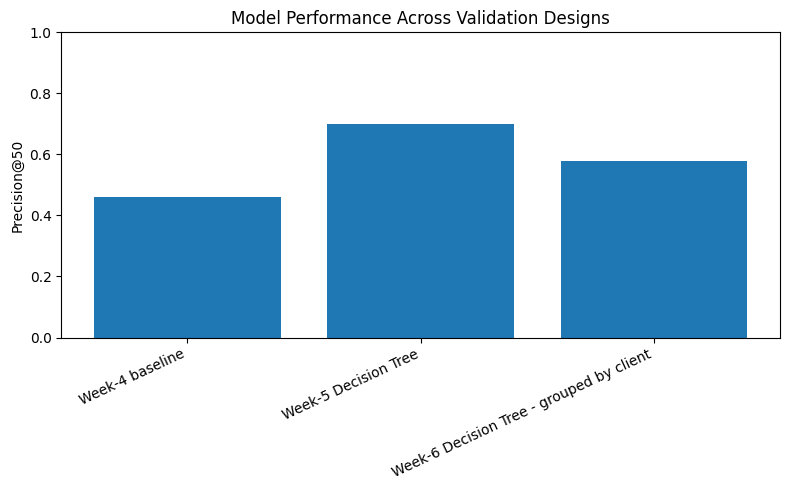

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Validation design"],
    comparison["Precision@50"]
)

plt.ylabel("Precision@50")
plt.title("Model Performance Across Validation Designs")
plt.xticks(rotation=25, ha="right")
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

# ML-12 — Showcase Materials

## 1. 5-Minute Demo Outline

### Question — 45 seconds
Can observable search and content signals help prioritize pages that may need content attention?

### Method — 1 minute
I used the FlyRank ML Internship dataset and built a Decision Tree using observable content and search-performance signals. I first compared the model with a Week-4 baseline, then tested the model using a grouped-by-client validation design to reduce the risk of overly optimistic results.

### One Chart — 45 seconds
Show the model-versus-baseline Precision@50 comparison.

The Week-4 baseline achieved 0.46 Precision@50. The Week-5 Decision Tree achieved 0.70 on the random split. Under the more conservative grouped-by-client validation, the model achieved 0.58 Precision@50.

### Honest Result — 1 minute
The model performed better than the Week-4 baseline on the measured Precision@50 metric. However, performance decreased from 0.70 on the random split to 0.58 when clients were separated between training and testing. This suggests that the random-split result may have been optimistic, so the grouped result is the more cautious estimate for decision-support use.

### Recommendation — 30 seconds
Use the ranked output as a prioritization queue for human review. Pages should not be automatically changed based only on the model because the model identifies directional signals rather than proving that a content refresh will improve search performance.

---

## 2. Social Post

I built a content-prioritization model using the FlyRank ML Internship dataset, focusing on observable search and content signals.

I compared a simple baseline with a Decision Tree and then tested the model using grouped-by-client validation to make the evaluation more conservative. Precision@50 improved from 0.46 for the baseline to 0.70 on the random split, while the grouped-by-client result was 0.58.

The main lesson was that validation design matters: a stronger-looking random-split result does not automatically mean the model will generalize to unseen clients. The final output is intended as decision-support for human review, not automated content changes.

---

## 3. Employer-Facing Summary

I built an end-to-end content-prioritization workflow using the FlyRank ML Internship dataset, including data validation, a baseline, a Decision Tree model, leakage checks, grouped-by-client validation, and an action playbook.

The model measured 0.70 Precision@50 on the Week-5 random split compared with 0.46 for the baseline, while the more conservative grouped-by-client validation measured 0.58 Precision@50.

The project showed me how to move from raw search data to a measurable ML workflow while keeping validation, leakage, model limitations, and human review central to the final recommendations.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
